In [6]:
#setup and imports 
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns
#make plots look clean by default
sns.set_theme(style="whitegrid")
#optional: show all columnn in outputs
pd.set_option("display.max_columns", 50)

In [7]:
df = pd.read_csv(r"C:\Users\hp\Downloads\Sales_Data.csv")
df.head()

,Region,Country,Item_Type,Sales_Channel,Order_Priority,Order_Date,Order_ID,Ship_Date,Units_Sold,Unit_SellingPrice,Unit_MakingCost,Total_Revenue,Total_Cost,Total_Profit
0,Central America and the Caribbean,Antigua and Barbuda,Baby Food,Online,M,12/20/2013,957081544.0,01-11-2014,552,255.28,159.42,140914.56,87999.84,52914.72
1,Central America and the Caribbean,Panama,Snacks,Offline,C,07-05-2010,301644504.0,7/26/2010,2167,152.58,97.44,330640.86,211152.48,119488.38
2,Europe,Czech Republic,Beverages,Offline,C,09-12-2011,478051030.0,9/29/2011,4778,47.45,31.79,226716.10,151892.62,74823.48
3,Asia,North Korea,Cereal,Offline,L,5/13/2010,892599952.0,6/15/2010,9016,205.70,117.11,1854591.20,1055863.76,798727.44
4,Asia,Sri Lanka,Snacks,Offline,C,7/20/2015,571902596.0,7/27/2015,7542,152.58,97.44,1150758.36,734892.48,415865.88


# quick dataset  check (shape column and missing values)

In [8]:
print("shape:",df.shape)
print("\ncolumns:",list(df.columns))
df.info()

shape: (5000, 14)

columns: ['Region', 'Country', 'Item_Type', 'Sales_Channel', 'Order_Priority', 'Order_Date', 'Order_ID', 'Ship_Date', 'Units_Sold', 'Unit_SellingPrice', 'Unit_MakingCost', 'Total_Revenue', 'Total_Cost', 'Total_Profit']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Region             5000 non-null   object 
 1   Country            5000 non-null   object 
 2   Item_Type          4989 non-null   object 
 3   Sales_Channel      5000 non-null   object 
 4   Order_Priority     5000 non-null   object 
 5   Order_Date         5000 non-null   object 
 6   Order_ID           4997 non-null   float64
 7   Ship_Date          5000 non-null   object 
 8   Units_Sold         5000 non-null   int64  
 9   Unit_SellingPrice  5000 non-null   float64
 10  Unit_MakingCost    5000 non-null   float64
 11  Total_Revenue      5000 no

# basic data cleaning + data parsing(important for time series plots)
we will convert order_date and ship_date to datetimeand create
order_year
order_month
#order_yearmonth(for monthly trend)


In [9]:
#convert dates 
df["Order_Date"] = pd.to_datetime(df["Order_Date"],errors="coerce")
df["Ship_Date"] = pd.to_datetime(df["Ship_Date"], errors="coerce")

#feature engineering for time analysis
df["order_year"] = df["Order_Date"].dt.year
df["order_month"] = df["Order_Date"].dt.month
df["order_yearmonth"] = df["Order_Date"].dt.to_period("M").astype(str)
df[["Order_Date","Ship_Date","order_year" , "order_month","order_yearmonth"]].head()

,Order_Date,Ship_Date,order_year,order_month,order_yearmonth
0,2013-12-20,2014-01-11,2013.0,12.0,2013-12
1,NaT,NaT,NaN,NaN,NaT
2,NaT,NaT,NaN,NaN,NaT
3,2010-05-13,NaT,2010.0,5.0,2010-05
4,2015-07-20,NaT,2015.0,7.0,2015-07


# matplotlib 
1.line plot(trend over time)
2.bar chart(category comparision)
3.histogram(distribution)

# line chart

In [10]:
# x axis must be categorical and y axis must be numerical
#use case trend/seasonality over time
df.head(2)


,Region,Country,Item_Type,Sales_Channel,Order_Priority,Order_Date,Order_ID,Ship_Date,Units_Sold,Unit_SellingPrice,Unit_MakingCost,Total_Revenue,Total_Cost,Total_Profit,order_year,order_month,order_yearmonth
0,Central America and the Caribbean,Antigua and Barbuda,Baby Food,Online,M,2013-12-20,957081544.0,2014-01-11,552,255.28,159.42,140914.56,87999.84,52914.72,2013.0,12.0,2013-12
1,Central America and the Caribbean,Panama,Snacks,Offline,C,NaT,301644504.0,NaT,2167,152.58,97.44,330640.86,211152.48,119488.38,NaN,NaN,NaT


In [11]:
monthly = (
    df.groupby("order_year" , as_index=False)["Units_Sold"]
    .sum()
    .sort_values("order_year")
)
monthly.head()

,order_year,Units_Sold
0,2010.0,1976592
1,2011.0,2023393
2,2012.0,2111040
3,2013.0,2008702
4,2014.0,1915167


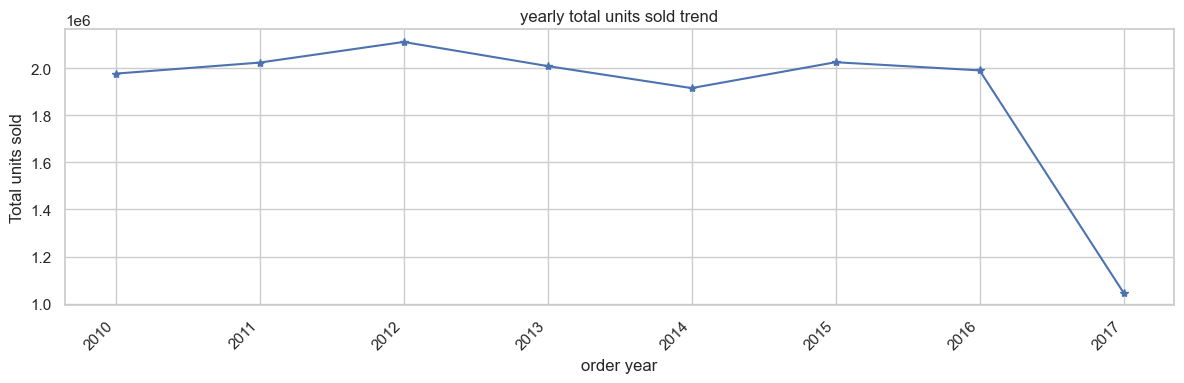

In [12]:
#line chart 
plt.figure(figsize=(12,4))
plt.plot(monthly["order_year"],monthly["Units_Sold"],marker="*")
plt.title("yearly total units sold trend")
plt.xlabel("order year")
plt.ylabel("Total units sold")
# improve readability : show fewer x-tickets 
step = max(1, len(monthly)//12)
plt.xticks(monthly["order_year"][::step], rotation=45, ha="right")
plt.grid(True)
plt.tight_layout()
plt.show()

# bar chart

In [13]:
#bar chart 
region_rev = (
    df.groupby("Region" , as_index=False)["Total_Revenue"]
    .sum()
    .sort_values("Total_Revenue" , ascending=False)
)

region_rev.head()

,Region,Total_Revenue
6,Sub-Saharan Africa,1.814567e+09
3,Europe,1.703622e+09
0,Asia,9.202771e+08
4,Middle East and North Africa,7.668678e+08
2,Central America and the Caribbean,6.849763e+08


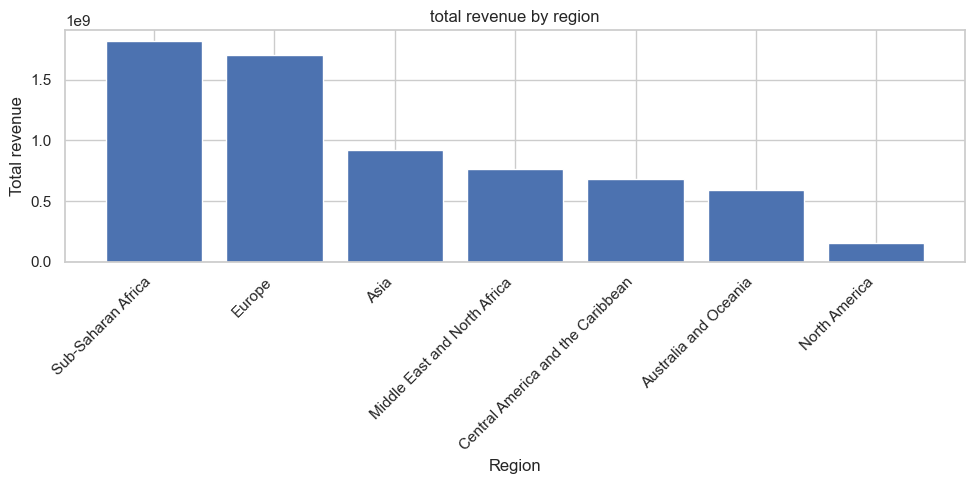

In [14]:
plt.figure(figsize=(10,5))
plt.bar(region_rev["Region"],region_rev["Total_Revenue"])
plt.title("total revenue by region")
plt.xlabel("Region")
plt.ylabel("Total revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Histogram

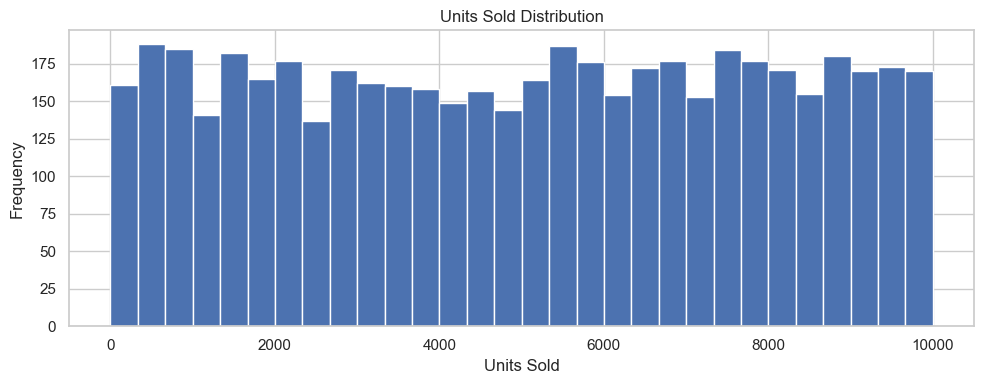

In [15]:
plt.figure(figsize=(10,4))
plt.hist(df["Units_Sold"], bins=30)
plt.title("Units Sold Distribution")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


Saved: monthly_revenue_trend.png


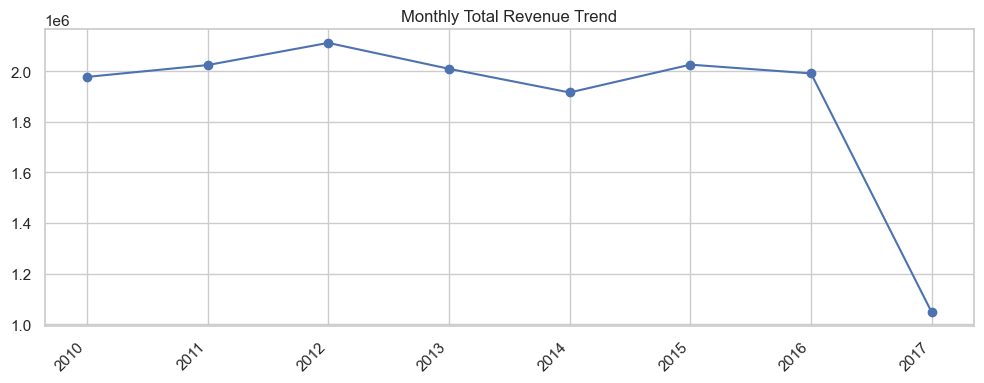

In [16]:
#save example figure
plt.figure(figsize=(10,4))
plt.plot(monthly["order_year"],monthly["Units_Sold"], marker="o")
plt.xticks(monthly["order_year"][::step], rotation=45, ha="right")
plt.title("Monthly Total Revenue Trend")
plt.tight_layout()
plt.savefig("monthly_revenue_trend.png", dpi=300, bbox_inches="tight")
print("Saved: monthly_revenue_trend.png")



# seaborn

# scatter plot
two numerical values 

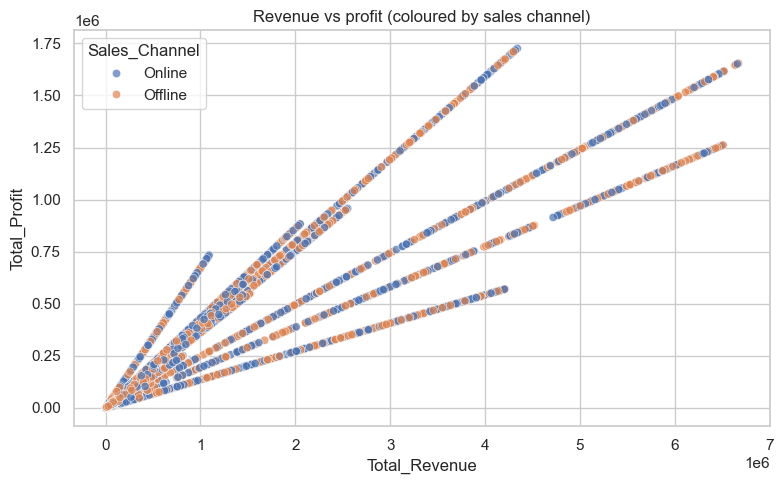

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Total_Revenue",
    y="Total_Profit",
    hue="Sales_Channel",
    alpha=0.7
)
plt.title("Revenue vs profit (coloured by sales channel)")
plt.tight_layout()
plt.show()

    


# violin plot 
use case : show full distribution shape +  median ragion




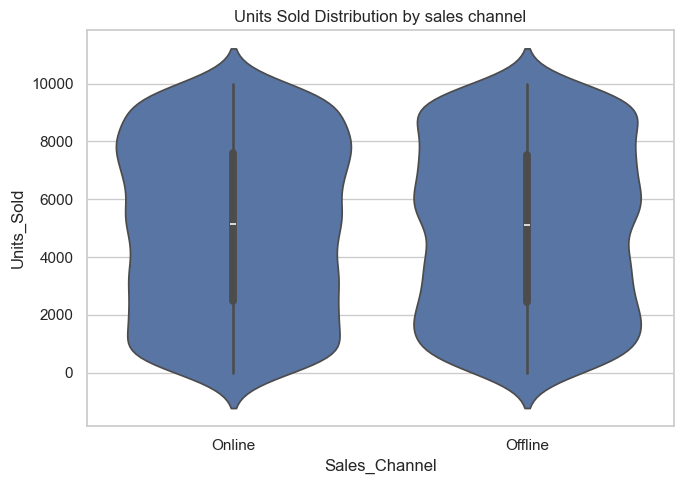

In [18]:
plt.figure(figsize=(7,5))
sns.violinplot(data=df, x="Sales_Channel", y="Units_Sold")
plt.title("Units Sold Distribution by sales channel")
plt.tight_layout()
plt.show()


# countplot

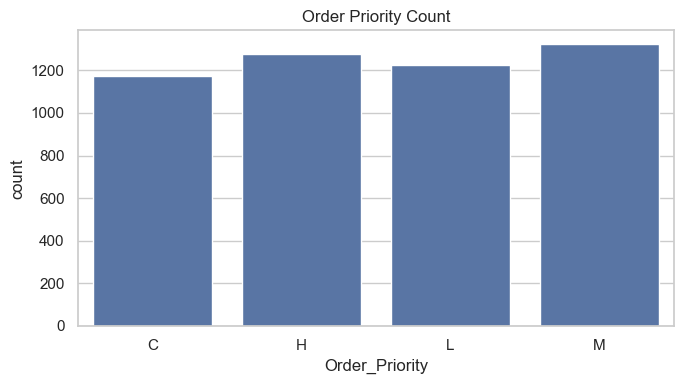

In [26]:
#use case category counts

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Order_Priority", order=sorted(df["Order_Priority"].dropna().unique()))
plt.title("Order Priority Count")
plt.tight_layout()
plt.show()
              

# heatmap

In [20]:
df.head(2)

,Region,Country,Item_Type,Sales_Channel,Order_Priority,Order_Date,Order_ID,Ship_Date,Units_Sold,Unit_SellingPrice,Unit_MakingCost,Total_Revenue,Total_Cost,Total_Profit,order_year,order_month,order_yearmonth
0,Central America and the Caribbean,Antigua and Barbuda,Baby Food,Online,M,2013-12-20,957081544.0,2014-01-11,552,255.28,159.42,140914.56,87999.84,52914.72,2013.0,12.0,2013-12
1,Central America and the Caribbean,Panama,Snacks,Offline,C,NaT,301644504.0,NaT,2167,152.58,97.44,330640.86,211152.48,119488.38,NaN,NaN,NaT


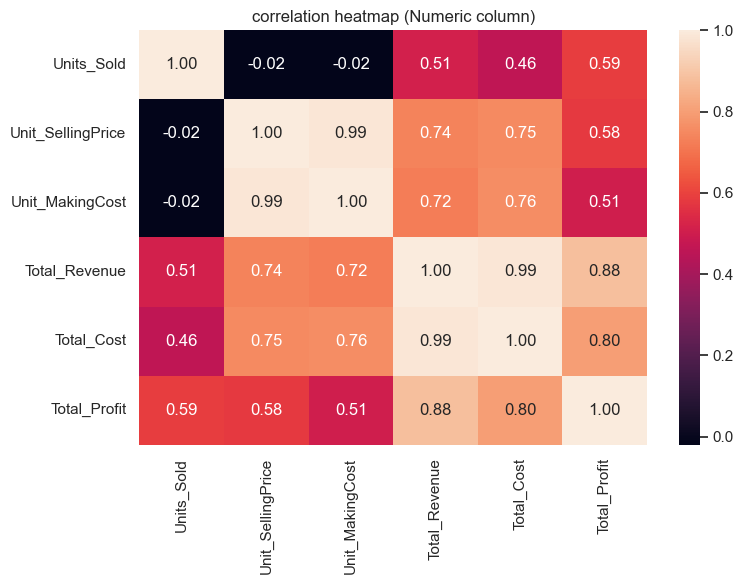

In [23]:
#quickly see relationships between metrics
num_cols = ["Units_Sold","Unit_SellingPrice","Unit_MakingCost","Total_Revenue","Total_Cost","Total_Profit"]
corr = df[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("correlation heatmap (Numeric column)")
plt.tight_layout()
plt.show()
